# BLINK IT SALES ANALYSIS - PYTHON PROJECT

### IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as pyxl
import plotly.express as px

### IMPORT RAW DATA

In [3]:
df=pd.read_csv(r"C:\Users\prateek\Downloads\blinkit_data.csv")

### SAMPLE DATA

In [4]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [5]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


### METADATA

In [6]:
print("No. of rows:",df.shape[0])
print("No. of colunms:", df.shape[1])

No. of rows: 8523
No. of colunms: 12


In [7]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [9]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


### DATA TYPES

In [10]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### DATA CLEANING

In [11]:
print(df['Item Fat Content'].unique())   

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [12]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat' ,
                                                         'low fat' : 'Low Fat' ,
                                                         'reg' : 'Regular'})

## BUSINESS REQUIREMENT'S

## KPI's

### TOTAL SALES

In [13]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [14]:
total_sales = df['Sales'].sum()
print("Total sales:",round(total_sales,2))

Total sales: 1201681.48


### AVEGARE SALES

In [15]:
avg_sales = df['Sales'].mean()
print("Avg sales:", round(avg_sales,1))

Avg sales: 141.0


### NUMBER OF ITEMS SOLD

In [16]:
total_sales = df['Sales'].count()
print("Total sales:", round(total_sales,2))

Total sales: 8523


### AVEGARE RATING

In [17]:
avg_rating = df['Rating'].mean()
print("avg_rating:", round(avg_rating,1))

avg_rating: 4.0


## CHART'S REQUIREMENT

### TOTAL SALES BY FAT CONTENT

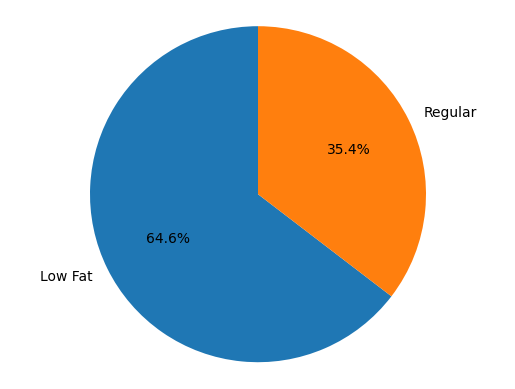

In [18]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels = sales_by_fat.index,
                    autopct = '%.1f%%',
                    startangle = 90)
plt.axis("equal")
plt.show()


### TOTAL SALES BY ITEM CONTENT

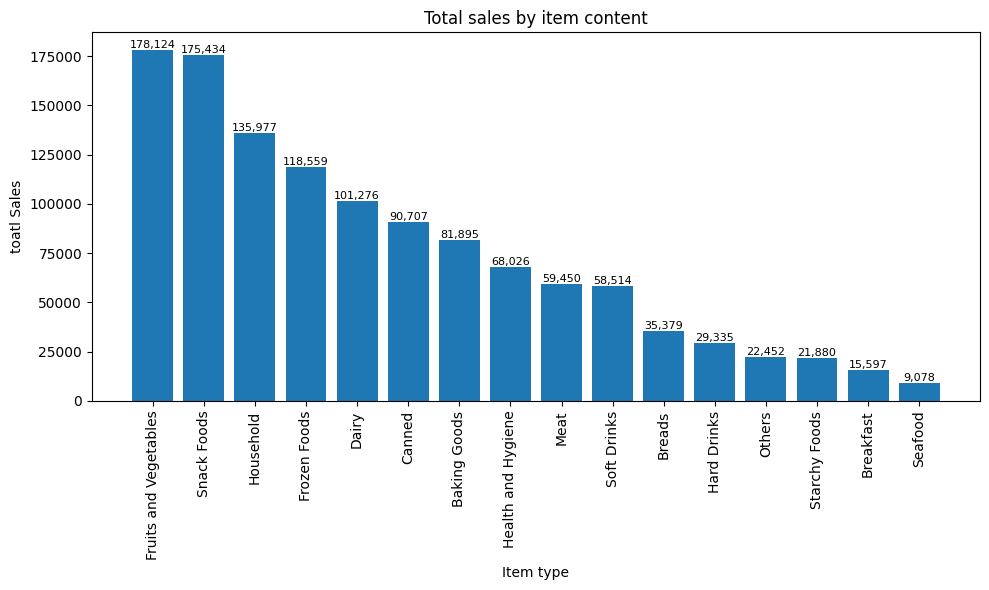

In [19]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation = 90)
plt.xlabel('Item type')
plt.ylabel('toatl Sales')
plt.title('Total sales by item content')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize=8)
plt.tight_layout()
plt.show()
 

### FAT CONTENT BY OUTLET FOR TOTAL SALES

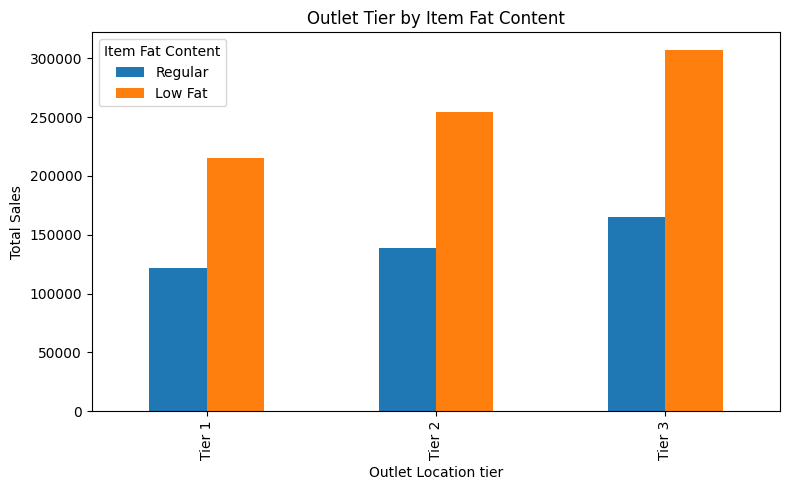

In [20]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()
 



### TOTAL SALES BY OUTLET ESTABLISMENT

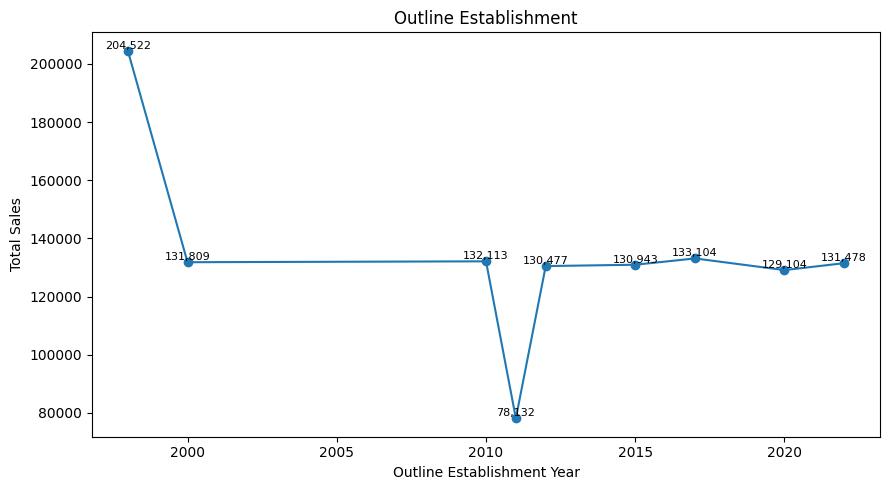

In [21]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index,sales_by_year.values,marker='o',linestyle='-')

plt.xlabel('Outline Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outline Establishment')

for x,y in zip(sales_by_year.index,sales_by_year.values):
    plt.text(x,y, f'{y:,.0f}', ha = 'center', va = 'bottom', fontsize=8)
    
plt.tight_layout()
plt.show()

### SALES BY OUTLET SIZE

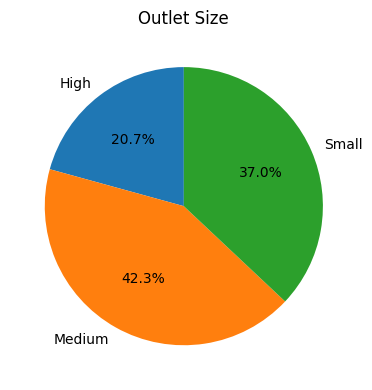

In [22]:
sales_by_outlet = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_outlet, labels = sales_by_outlet.index, autopct = '%1.1f%%', startangle = 90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

### SALES BY OUTLET LOCATION

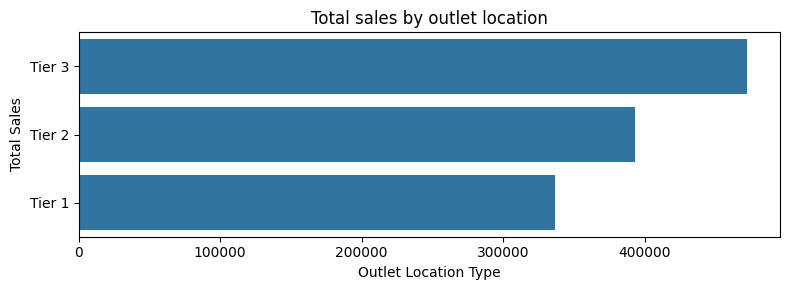

In [24]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,3))
ax = sns.barplot(x='Sales', y='Outlet Location Type', data = sales_by_location)

plt.title('Total sales by outlet location')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()
                 